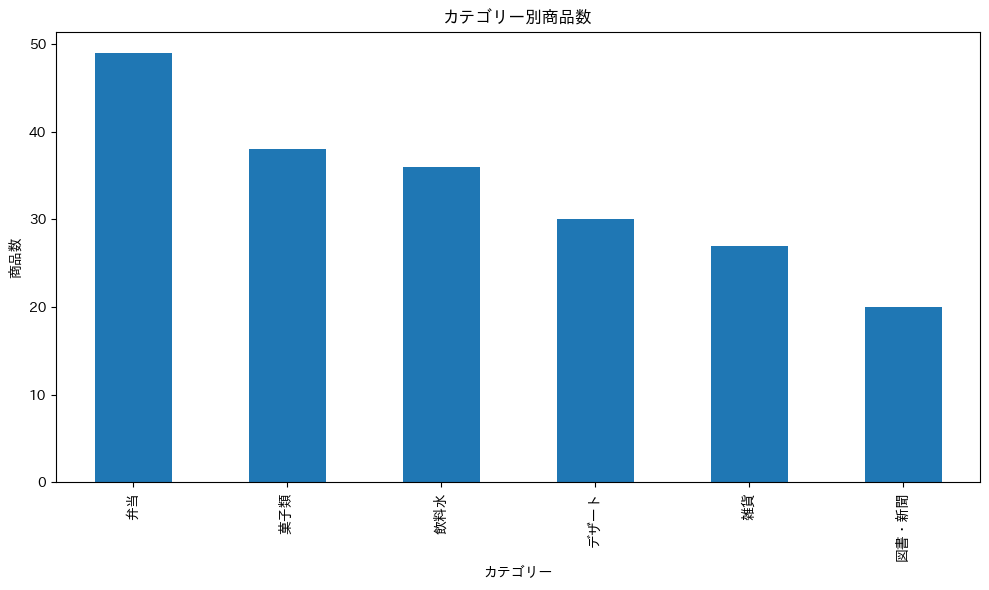

,count,mean,std,min,25%,50%,75%,max
商品番号,,,,,,,,
1QJFO8QY,32.0,600.0,0.0,600.0,600.0,600.0,600.0,600.0
2HSTCDWM,20.0,300.0,0.0,300.0,300.0,300.0,300.0,300.0
48XMJXKO,10.0,330.0,0.0,330.0,330.0,330.0,330.0,330.0
8T7D5DQA,21.0,120.0,0.0,120.0,120.0,120.0,120.0,120.0
MESUDVWQ,17.0,660.0,0.0,660.0,660.0,660.0,660.0,660.0
QRMOGNUU,27.0,420.0,0.0,420.0,420.0,420.0,420.0,420.0
S6RE8W6X,20.0,720.0,0.0,720.0,720.0,720.0,720.0,720.0
X0ZE2ZMY,14.0,90.0,0.0,90.0,90.0,90.0,90.0,90.0
YY4HAAZR,17.0,780.0,0.0,780.0,780.0,780.0,780.0,780.0


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib


df = pd.read_csv("sample_pandas_6.csv")

def tax(x):
    return x * 1.10

df['単価'].apply(tax)
df['発注日'] = pd.to_datetime(df['発注日'])
tax_series = df['単価'].apply(tax)
tax_series.name = "単価（税込み）"
pd.concat([df, tax_series], axis=1)

category_df = pd.read_csv('category.csv')
df = pd.merge(df, category_df[['商品番号', 'カテゴリー']], how='inner', on='商品番号')

df_category = df['カテゴリー'].value_counts()

plt.figure(figsize=(10, 6))
df_category.plot(kind='bar')
plt.title('カテゴリー別商品数')
plt.xlabel('カテゴリー')
plt.ylabel('商品数')
plt.tight_layout()

plt.show()

df.groupby('商品番号')['単価'].describe()